# Membership EDA: 100원 vs 일반 요금
price == 100 (프로모션/무료체험) vs price != 100 (유료 구독자) 비교

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('../data/02_interim/260430 전처리 수정/membership_v1.csv', encoding='utf-8-sig')
df['is_100'] = (df['price'] == 100).astype(int)
df['price_label'] = df['is_100'].map({1: '100원', 0: '일반요금'})

g100  = df[df['is_100'] == 1]
g_etc = df[df['is_100'] == 0]

print(f'전체: {len(df):,}건')
print(f'100원: {len(g100):,}건 ({len(g100)/len(df)*100:.1f}%)')
print(f'일반 요금: {len(g_etc):,}건 ({len(g_etc)/len(df)*100:.1f}%)')
df.head(3)

전체: 17,876건
100원: 9,061건 (50.7%)
일반 요금: 8,815건 (49.3%)


,USER_KEY,product_code,price,billing_method,max_screen,is_promotion,is_churn_prevented,is_repurchase,payment_device,is_user_verified,gender,age,reg_date,reg_hour,end_date,is_100,price_label
0,7a6960912bebe03c6e4c770eb1aa91329c3497f18f90ca...,pk_1489,100.0,134,4,1,0,0,pc,1,F,20,2021-03-14,20,2021-04-14,1,100원
1,4ec765db76545c1d6dda9f421590bf9d02f584009f8d92...,pk_1487,100.0,190,1,1,1,0,pc,1,F,25,2021-03-09,14,2021-04-09,1,100원
2,4f86d917c53cb6bd8949f76dba7260311e8c1748748a02...,pk_1487,100.0,132,1,1,0,0,android,1,F,55,2021-03-09,22,2021-04-09,1,100원


---
## 1. product_code

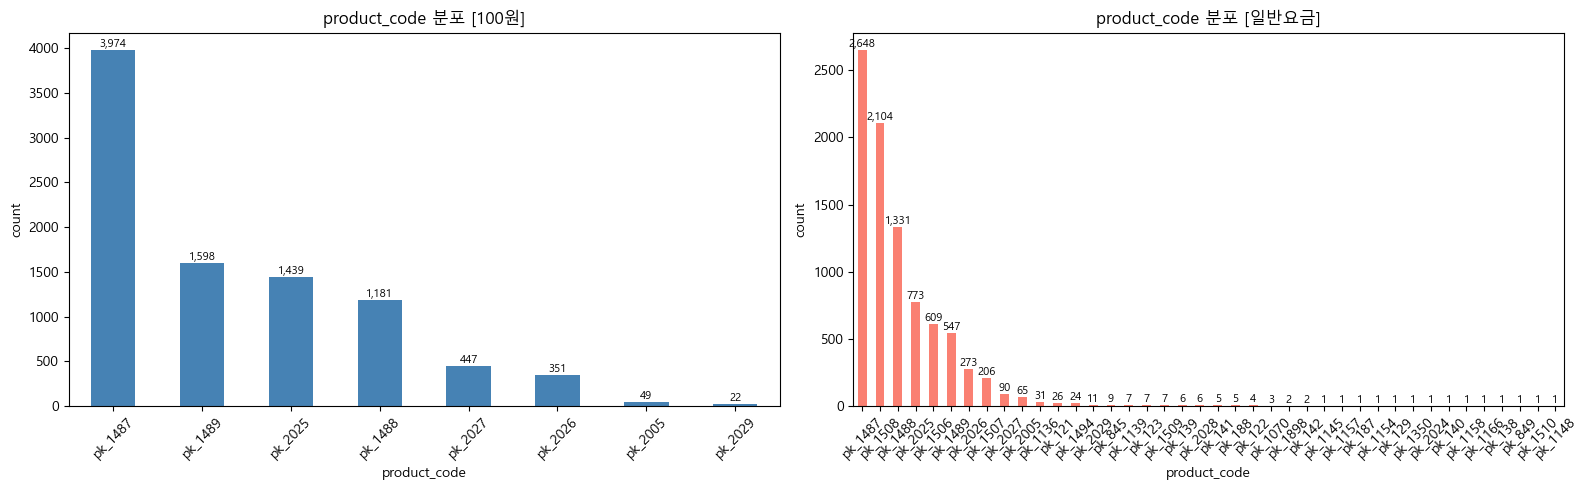

               100원   일반요금
product_code              
pk_1070        0.00   0.03
pk_1136        0.00   0.35
pk_1139        0.00   0.08
pk_1145        0.00   0.01
pk_1148        0.00   0.01
pk_1154        0.00   0.01
pk_1157        0.00   0.01
pk_1158        0.00   0.01
pk_1166        0.00   0.01
pk_121         0.00   0.29
pk_122         0.00   0.05
pk_123         0.00   0.08
pk_129         0.00   0.01
pk_1350        0.00   0.01
pk_138         0.00   0.01
pk_139         0.00   0.07
pk_140         0.00   0.01
pk_141         0.00   0.06
pk_142         0.00   0.02
pk_1487       43.86  30.04
pk_1488       13.03  15.10
pk_1489       17.64   6.21
pk_1494        0.00   0.27
pk_1506        0.00   6.91
pk_1507        0.00   2.34
pk_1508        0.00  23.87
pk_1509        0.00   0.08
pk_1510        0.00   0.01
pk_187         0.00   0.01
pk_188         0.00   0.06
pk_1898        0.00   0.02
pk_2005        0.54   0.74
pk_2024        0.00   0.01
pk_2025       15.88   8.77
pk_2026        3.87   3.10
p

In [2]:
col = 'product_code'

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (label, sub) in zip(axes, [('100원', g100), ('일반요금', g_etc)]):
    cnt = sub[col].value_counts()
    cnt.plot(kind='bar', ax=ax, color='steelblue' if label=='100원' else 'salmon')
    ax.set_title(f'{col} 분포 [{label}]')
    ax.set_xlabel(col)
    ax.set_ylabel('count')
    ax.tick_params(axis='x', rotation=45)
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

# 비율 비교
comp = pd.DataFrame({
    '100원': g100[col].value_counts(normalize=True)*100,
    '일반요금': g_etc[col].value_counts(normalize=True)*100
}).fillna(0).round(2)
print(comp)

---
## 2. billing_method

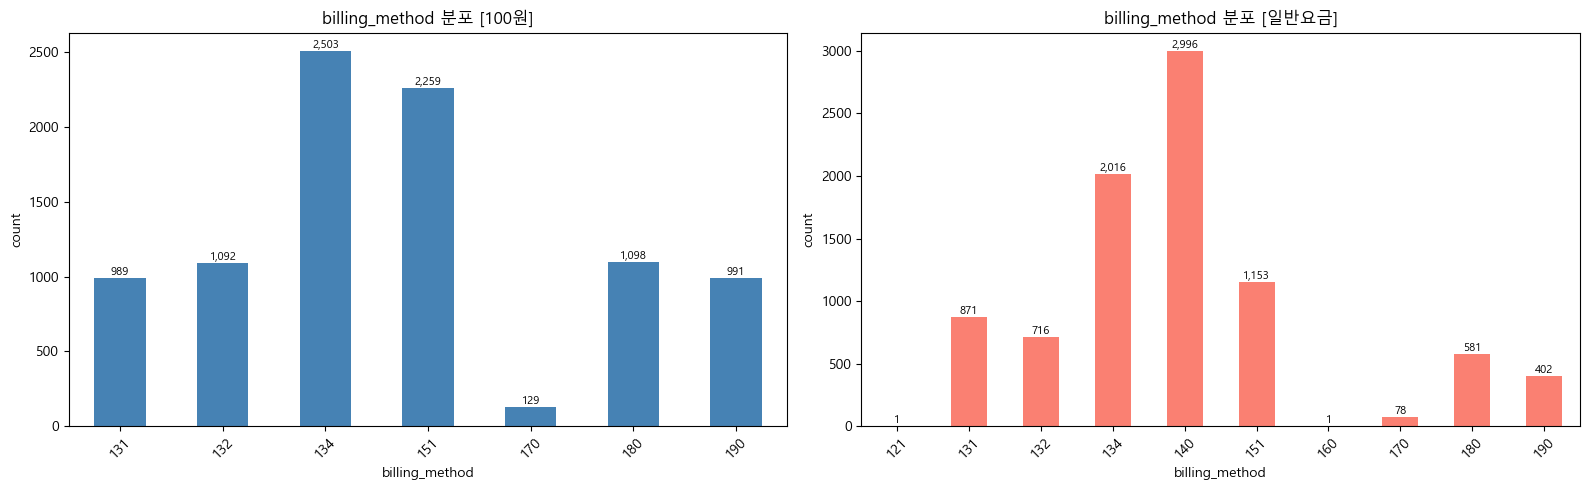

                 100원   일반요금
billing_method              
121              0.00   0.01
131             10.91   9.88
132             12.05   8.12
134             27.62  22.87
140              0.00  33.99
151             24.93  13.08
160              0.00   0.01
170              1.42   0.88
180             12.12   6.59
190             10.94   4.56


In [3]:
col = 'billing_method'

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (label, sub) in zip(axes, [('100원', g100), ('일반요금', g_etc)]):
    cnt = sub[col].value_counts().sort_index()
    cnt.plot(kind='bar', ax=ax, color='steelblue' if label=='100원' else 'salmon')
    ax.set_title(f'{col} 분포 [{label}]')
    ax.set_xlabel(col)
    ax.set_ylabel('count')
    ax.tick_params(axis='x', rotation=45)
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

comp = pd.DataFrame({
    '100원': g100[col].value_counts(normalize=True)*100,
    '일반요금': g_etc[col].value_counts(normalize=True)*100
}).fillna(0).sort_index().round(2)
print(comp)

---
## 3. max_screen

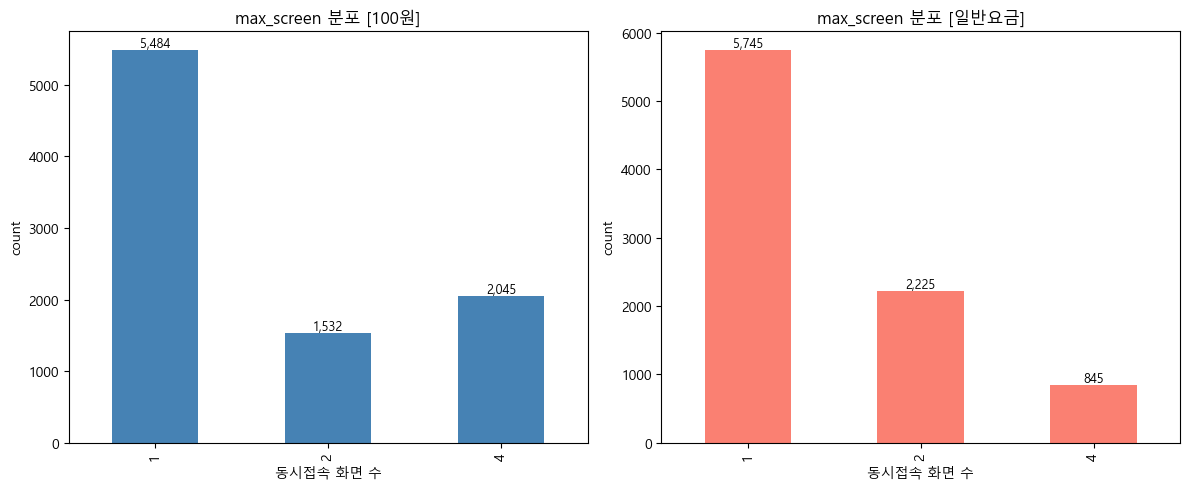

             100원   일반요금
max_screen              
1           60.52  65.17
2           16.91  25.24
4           22.57   9.59


In [4]:
col = 'max_screen'

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (label, sub) in zip(axes, [('100원', g100), ('일반요금', g_etc)]):
    cnt = sub[col].value_counts().sort_index()
    cnt.plot(kind='bar', ax=ax, color='steelblue' if label=='100원' else 'salmon')
    ax.set_title(f'{col} 분포 [{label}]')
    ax.set_xlabel('동시접속 화면 수')
    ax.set_ylabel('count')
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

comp = pd.DataFrame({
    '100원': g100[col].value_counts(normalize=True)*100,
    '일반요금': g_etc[col].value_counts(normalize=True)*100
}).fillna(0).sort_index().round(2)
print(comp)

---
## 4. is_promotion

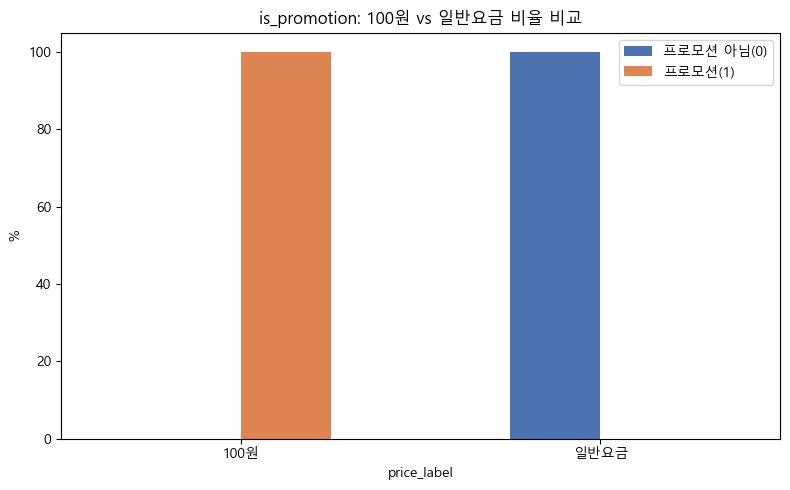

             프로모션 아님(0)  프로모션(1)
price_label                     
100원                0.0    100.0
일반요금              100.0      0.0


In [5]:
col = 'is_promotion'

cross = pd.crosstab(df['price_label'], df[col], normalize='index') * 100
cross.columns = ['프로모션 아님(0)', '프로모션(1)']

cross.plot(kind='bar', figsize=(8, 5), color=['#4C72B0','#DD8452'])
plt.title(f'{col}: 100원 vs 일반요금 비율 비교')
plt.ylabel('%')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()
print(cross.round(2))

---
## 5. is_churn_prevented

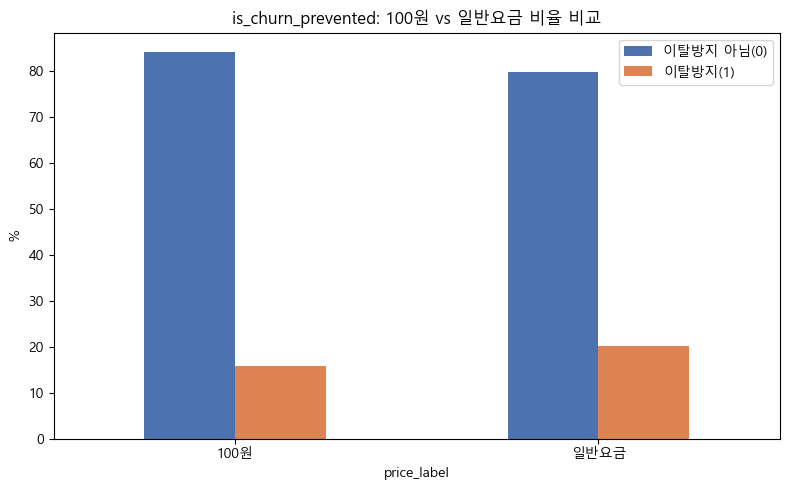

             이탈방지 아님(0)  이탈방지(1)
price_label                     
100원              84.21    15.79
일반요금              79.75    20.25


In [6]:
col = 'is_churn_prevented'

cross = pd.crosstab(df['price_label'], df[col], normalize='index') * 100
cross.columns = ['이탈방지 아님(0)', '이탈방지(1)']

cross.plot(kind='bar', figsize=(8, 5), color=['#4C72B0','#DD8452'])
plt.title(f'{col}: 100원 vs 일반요금 비율 비교')
plt.ylabel('%')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()
print(cross.round(2))

---
## 6. is_repurchase

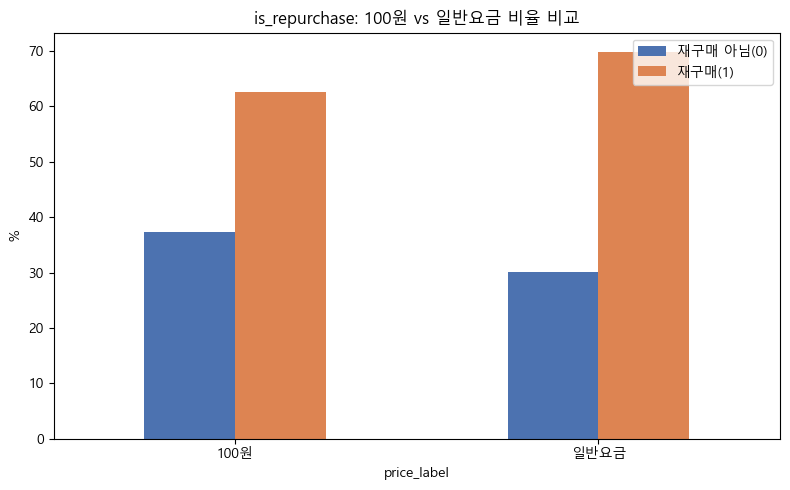

             재구매 아님(0)  재구매(1)
price_label                   
100원             37.37   62.63
일반요금             30.16   69.84


In [7]:
col = 'is_repurchase'

cross = pd.crosstab(df['price_label'], df[col], normalize='index') * 100
cross.columns = ['재구매 아님(0)', '재구매(1)']

cross.plot(kind='bar', figsize=(8, 5), color=['#4C72B0','#DD8452'])
plt.title(f'{col}: 100원 vs 일반요금 비율 비교')
plt.ylabel('%')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()
print(cross.round(2))

---
## 7. payment_device

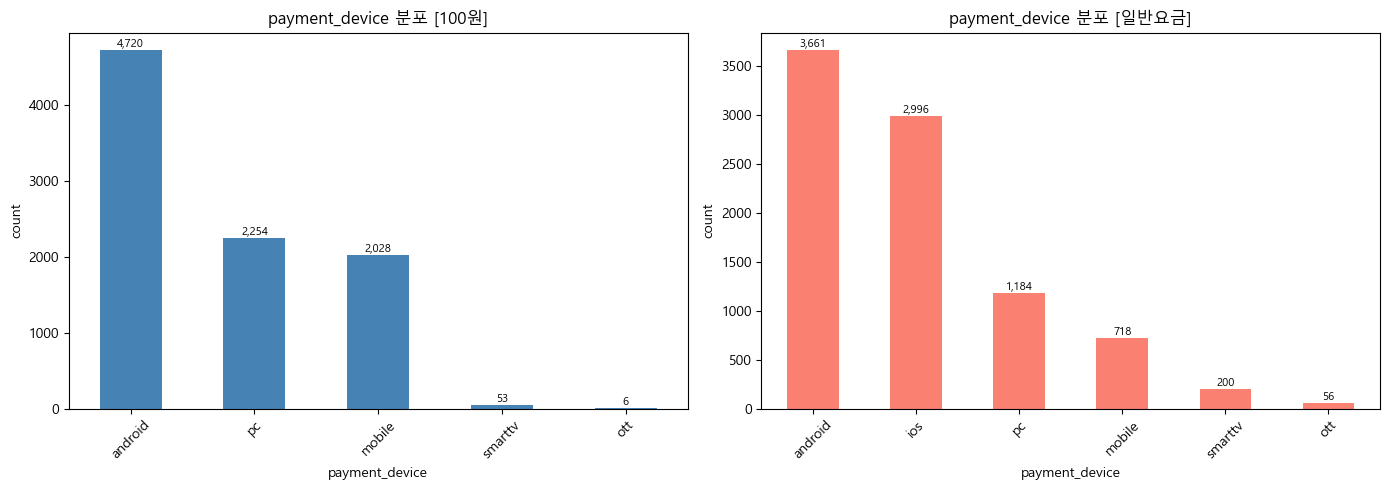

                 100원   일반요금
payment_device              
android         52.09  41.53
ios              0.00  33.99
mobile          22.38   8.15
ott              0.07   0.64
pc              24.88  13.43
smarttv          0.58   2.27


In [8]:
col = 'payment_device'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (label, sub) in zip(axes, [('100원', g100), ('일반요금', g_etc)]):
    cnt = sub[col].value_counts()
    cnt.plot(kind='bar', ax=ax, color='steelblue' if label=='100원' else 'salmon')
    ax.set_title(f'{col} 분포 [{label}]')
    ax.set_xlabel(col)
    ax.set_ylabel('count')
    ax.tick_params(axis='x', rotation=45)
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

comp = pd.DataFrame({
    '100원': g100[col].value_counts(normalize=True)*100,
    '일반요금': g_etc[col].value_counts(normalize=True)*100
}).fillna(0).round(2)
print(comp)

---
## 8. is_user_verified

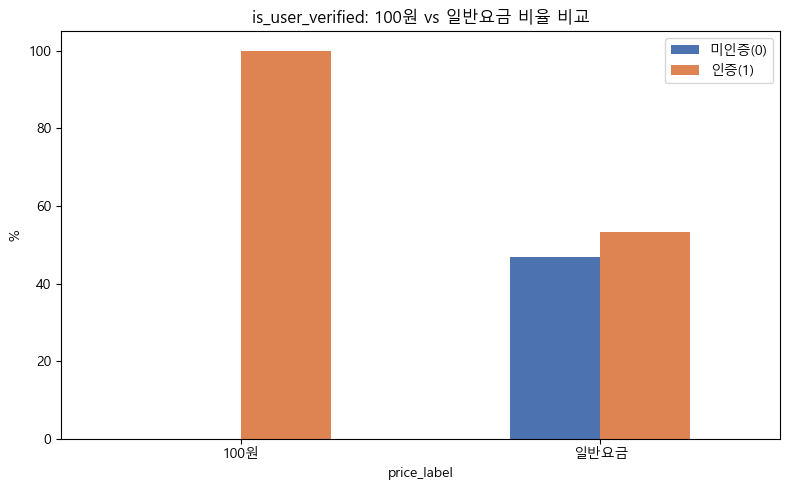

             미인증(0)   인증(1)
price_label                
100원           0.00  100.00
일반요금          46.75   53.25


In [9]:
col = 'is_user_verified'

cross = pd.crosstab(df['price_label'], df[col], normalize='index') * 100
cross.columns = ['미인증(0)', '인증(1)']

cross.plot(kind='bar', figsize=(8, 5), color=['#4C72B0','#DD8452'])
plt.title(f'{col}: 100원 vs 일반요금 비율 비교')
plt.ylabel('%')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()
print(cross.round(2))

---
## 9. gender

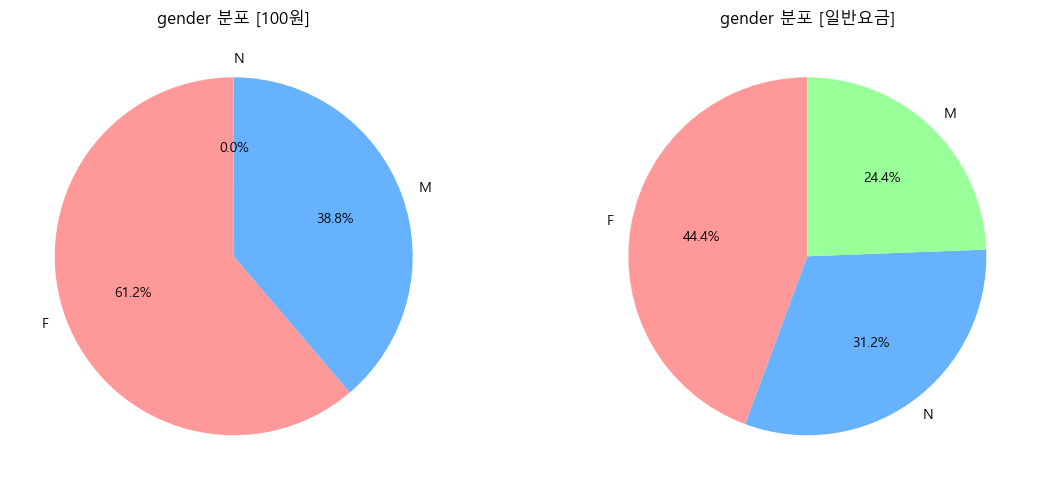

         100원   일반요금
gender              
F       61.23  44.37
M       38.76  24.40
N        0.01  31.23


In [10]:
col = 'gender'

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (label, sub) in zip(axes, [('100원', g100), ('일반요금', g_etc)]):
    cnt = sub[col].value_counts()
    ax.pie(cnt, labels=cnt.index, autopct='%1.1f%%', startangle=90,
           colors=['#FF9999','#66B2FF','#99FF99'])
    ax.set_title(f'gender 분포 [{label}]')
plt.tight_layout()
plt.show()

comp = pd.DataFrame({
    '100원': g100[col].value_counts(normalize=True)*100,
    '일반요금': g_etc[col].value_counts(normalize=True)*100
}).fillna(0).round(2)
print(comp)

---
## 10. age

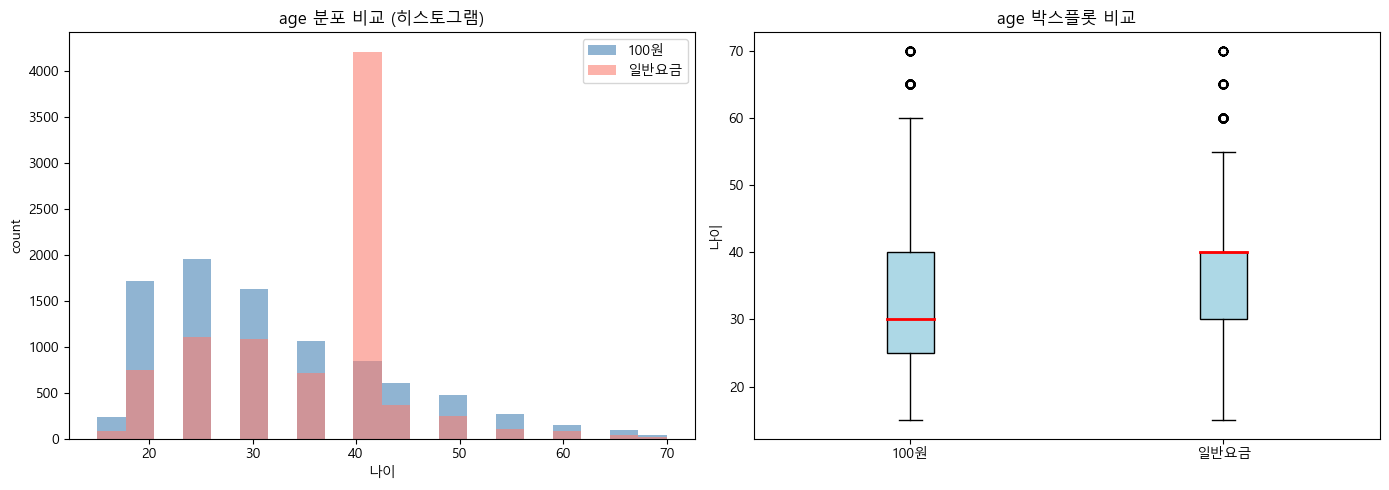

=== 100원 그룹 age 통계 ===
count    9061.00
mean       31.95
std        11.27
min        15.00
25%        25.00
50%        30.00
75%        40.00
max        70.00
Name: age, dtype: float64

=== 일반요금 그룹 age 통계 ===
count    8815.00
mean       35.59
std         8.86
min        15.00
25%        30.00
50%        40.00
75%        40.00
max        70.00
Name: age, dtype: float64


In [11]:
col = 'age'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램 비교
ax = axes[0]
ax.hist(g100[col], bins=20, alpha=0.6, label='100원', color='steelblue')
ax.hist(g_etc[col], bins=20, alpha=0.6, label='일반요금', color='salmon')
ax.set_title('age 분포 비교 (히스토그램)')
ax.set_xlabel('나이')
ax.set_ylabel('count')
ax.legend()

# 박스플롯 비교
ax = axes[1]
ax.boxplot([g100[col], g_etc[col]], labels=['100원', '일반요금'],
           patch_artist=True,
           boxprops=dict(facecolor='lightblue'),
           medianprops=dict(color='red', linewidth=2))
ax.set_title('age 박스플롯 비교')
ax.set_ylabel('나이')

plt.tight_layout()
plt.show()

print('=== 100원 그룹 age 통계 ===')
print(g100[col].describe().round(2))
print('\n=== 일반요금 그룹 age 통계 ===')
print(g_etc[col].describe().round(2))

---
## 11. reg_hour (가입 시간대)

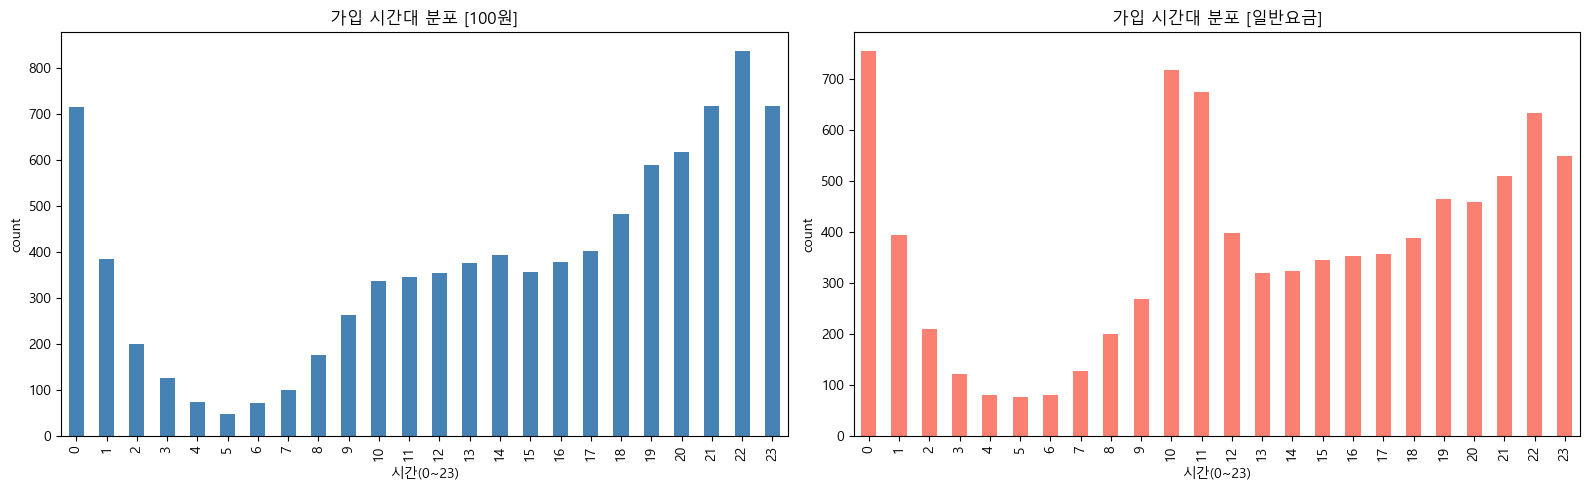

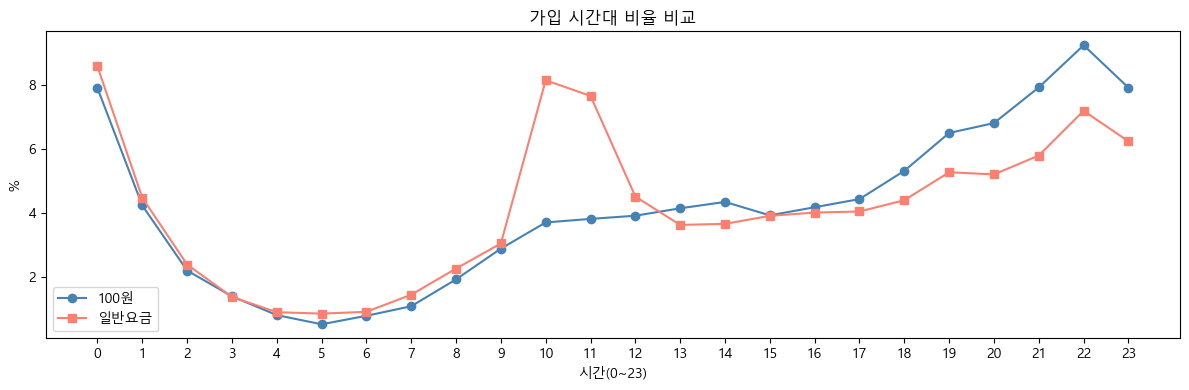

In [12]:
col = 'reg_hour'

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (label, sub) in zip(axes, [('100원', g100), ('일반요금', g_etc)]):
    cnt = sub[col].value_counts().sort_index()
    cnt.plot(kind='bar', ax=ax, color='steelblue' if label=='100원' else 'salmon')
    ax.set_title(f'가입 시간대 분포 [{label}]')
    ax.set_xlabel('시간(0~23)')
    ax.set_ylabel('count')
plt.tight_layout()
plt.show()

# 시간대별 비율 비교 꺾은선
r100 = g100[col].value_counts(normalize=True).sort_index() * 100
r_etc = g_etc[col].value_counts(normalize=True).sort_index() * 100
plt.figure(figsize=(12, 4))
plt.plot(r100.index, r100.values, marker='o', label='100원', color='steelblue')
plt.plot(r_etc.index, r_etc.values, marker='s', label='일반요금', color='salmon')
plt.title('가입 시간대 비율 비교')
plt.xlabel('시간(0~23)')
plt.ylabel('%')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

---
## 12. reg_date (가입 월별 추이)

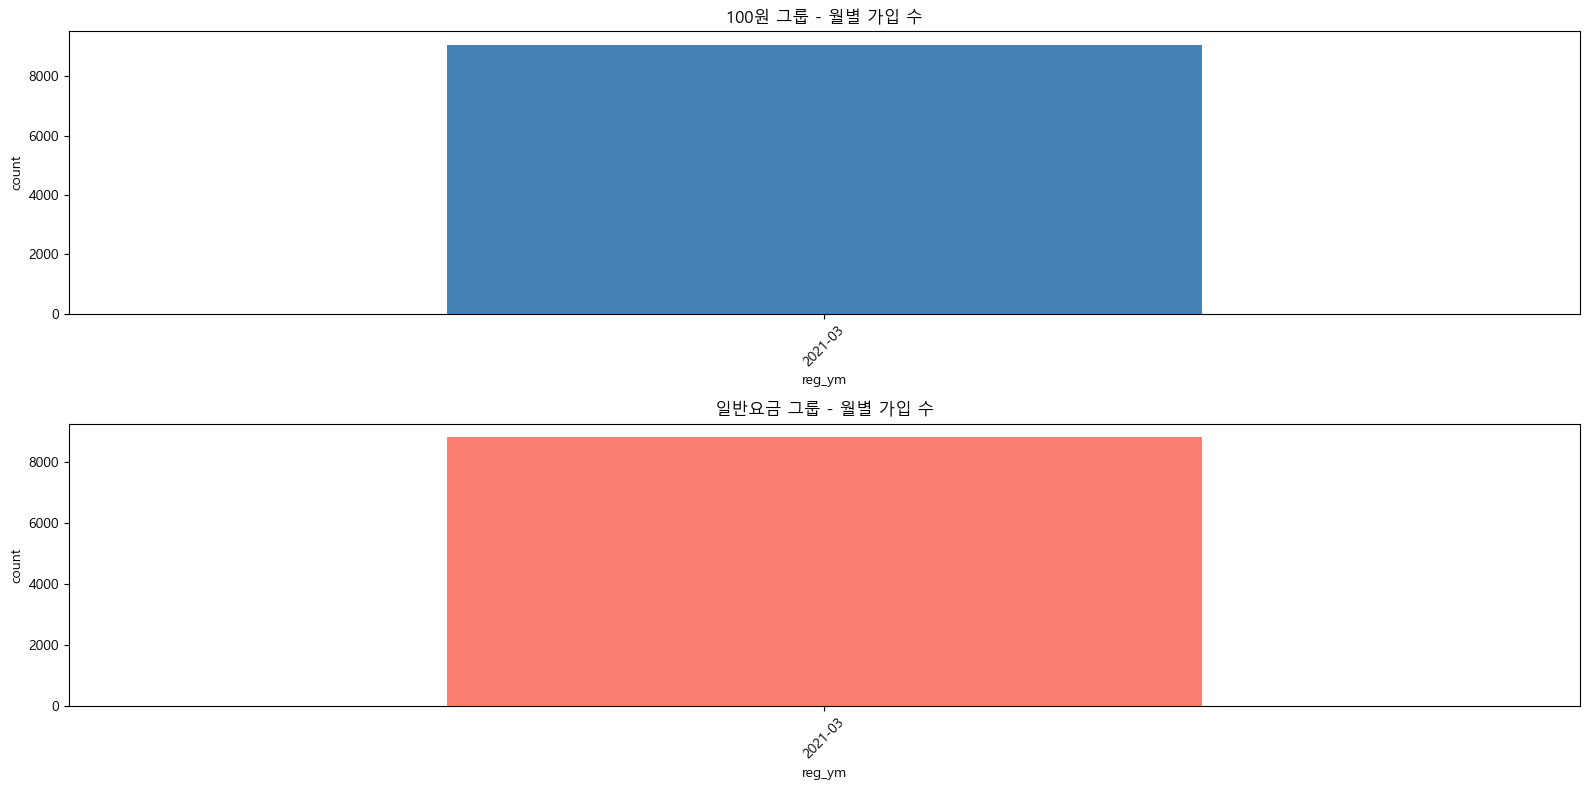

In [13]:
df['reg_ym'] = pd.to_datetime(df['reg_date']).dt.to_period('M').astype(str)

r100 = df[df['is_100']==1]['reg_ym'].value_counts().sort_index()
r_etc = df[df['is_100']==0]['reg_ym'].value_counts().sort_index()

fig, axes = plt.subplots(2, 1, figsize=(16, 8))
r100.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('100원 그룹 - 월별 가입 수')
axes[0].set_ylabel('count')
axes[0].tick_params(axis='x', rotation=45)

r_etc.plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('일반요금 그룹 - 월별 가입 수')
axes[1].set_ylabel('count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## 13. 종합 요약 테이블

In [14]:
binary_cols = ['is_promotion', 'is_churn_prevented', 'is_repurchase', 'is_user_verified']

summary = pd.DataFrame({
    '100원 비율(%)': [g100[c].mean()*100 for c in binary_cols],
    '일반요금 비율(%)': [g_etc[c].mean()*100 for c in binary_cols]
}, index=binary_cols).round(2)

print('=== 이진 변수 비율 요약 ===')
print(summary)

print('\n=== age 요약 ===')
age_summary = pd.DataFrame({
    '100원': g100['age'].describe(),
    '일반요금': g_etc['age'].describe()
}).round(2)
print(age_summary)

=== 이진 변수 비율 요약 ===
                    100원 비율(%)  일반요금 비율(%)
is_promotion            100.00        0.00
is_churn_prevented       15.79       20.25
is_repurchase            62.63       69.84
is_user_verified        100.00       53.25

=== age 요약 ===
          100원     일반요금
count  9061.00  8815.00
mean     31.95    35.59
std      11.27     8.86
min      15.00    15.00
25%      25.00    30.00
50%      30.00    40.00
75%      40.00    40.00
max      70.00    70.00
